# Bring your own data

Your lab's cycler almost certainly doesn't export columns named `cycle_number`/`capacity_ah`/
`soh_pct`. This notebook takes a CSV with realistic, different column names
(`notebooks/sample_data/my_lab_cell.csv` — a small synthetic fixture, not real cell data) and
maps it into batlab's standardized schema, validates it, and runs the same pipeline every
built-in loader's output can.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from batlab.datasets.schema import validate_schema, compute_soh_pct
from batlab.features import build_features, get_model_matrix
from batlab.models import train_models, predict

raw = pd.read_csv("sample_data/my_lab_cell.csv")
raw.head()

,Cycle,Cap_Ah,Temp_C
0,1,2.0488,23.1
1,2,2.0488,22.6
2,3,2.0453,22.9
3,4,2.0416,21.8
4,5,2.0421,22.3


## Map to the schema contract

`batlab.datasets.schema.REQUIRED_CYCLE_COLUMNS` needs `cycle_number`, `capacity_ah`, `soh_pct`.
Our raw export has `Cycle`, `Cap_Ah`, `Temp_C` — rename, then compute the one derived column
every batlab loader computes the same way (`compute_soh_pct`), rather than reimplementing the
formula by hand.

In [2]:
df = raw.rename(columns={"Cycle": "cycle_number", "Cap_Ah": "capacity_ah", "Temp_C": "temperature_c"})
df["soh_pct"] = compute_soh_pct(df["capacity_ah"])

df.attrs["cell_id"] = "my_lab_cell_01"
df.attrs["source"] = "user_upload"
df.attrs["chemistry"] = "unknown — set this to your cell's real chemistry"
df.attrs["citation"] = "n/a — your own data"
df.attrs["license"] = "n/a — your own data"

validate_schema(df, kind="cycle")
print("Schema valid.")
df.head()

Schema valid.


,cycle_number,capacity_ah,temperature_c,soh_pct
0,1,2.0488,23.1,100.000000
1,2,2.0488,22.6,100.000000
2,3,2.0453,22.9,99.829168
3,4,2.0416,21.8,99.648575
4,5,2.0421,22.3,99.672979


## Run the pipeline

From here on this is identical to every built-in loader's cell — same `build_features`, same model code.

In [3]:
featured = build_features(df)
X, y_soh, y_rul = get_model_matrix(featured)
print(f"{X.shape[0]} usable rows, {X.shape[1]} features")

118 usable rows, 11 features


Held-out test R2 -- SOH: -5.789, RUL: -2.147


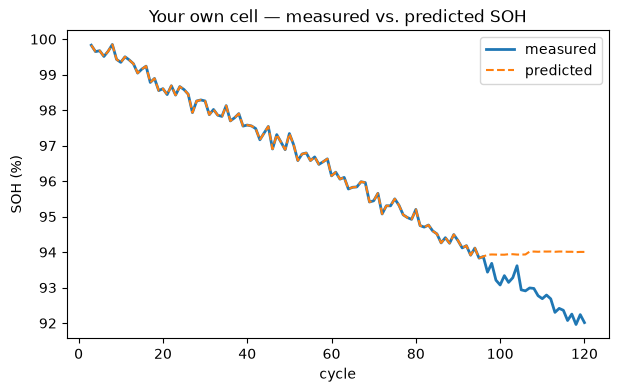

In [4]:
bundle = train_models(X, y_soh, y_rul)
print(f"Held-out test R2 -- SOH: {bundle['metrics']['soh_r2']:.3f}, RUL: {bundle['metrics']['rul_r2']:.3f}")

preds = predict(bundle, X)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X["cycle_number"], y_soh, label="measured", lw=2)
ax.plot(X["cycle_number"], preds["soh_pred"], label="predicted", lw=1.5, ls="--")
ax.set_xlabel("cycle"); ax.set_ylabel("SOH (%)"); ax.legend()
ax.set_title("Your own cell — measured vs. predicted SOH")
plt.show()

## One important honesty note

This is a **single cell**. `batlab.validation.run_lco()` needs 2+ cells to mean anything —
leave-*one*-out cross-validation on one cell is not defined. If you only have one cell's worth
of data, the R2 above is an in-sample chronological holdout (better than nothing, still not the
same claim as a validated cross-cell generalization number). Bring more cells before trusting
this the way you'd trust the quickstart notebook's 4-cell LCO result.

## Cite this

In [5]:
import batlab
print(batlab.cite())

@software{batlab,
  title  = {batlab: a citable, honest research library for battery degradation analysis},
  author = {Hosseini, Ali},
  year   = {2026},
  url    = {https://github.com/seyedali1996lb-svg/battery-intelligence-platform},
  note   = {Standardized dataset loaders, leave-cell-out-validated SOH/RUL models, and reproducible benchmark manifests.}
}
